In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, RobustScaler
from sklearn.linear_model import LassoCV
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import classification_report, f1_score, precision_recall_curve
from xgboost import XGBClassifier

# 1. 데이터 로드
df = pd.read_csv('/content/drive/MyDrive/전북대학교/공모전/경상국립대 ai,빅데이터 활용 서비스 개발/RIA_최종통합피쳐셋.csv').fillna(0)

# 2. 데이터 누수(Leakage) 컬럼 제거
# 사고가 발생한 후에만 알 수 있는 '결과' 변수들을 모두 리스트업하여 삭제합니다.
leakage_cols = [
    '사망자', '부상자', '총재해자', '외국인재해자', '외국인비율', '고령재해자', '고령자비율',
    '남성 사망자', '남성 부상자', '여성 사망자', '여성 부상자',
    '추락_낙하', '붕괴_도괴', '구조물_균열', '침수_수해', '장비_충돌', '화재_폭발', '기타',
    'C_RPI', '위험등급' # 기존에 계산된 결과값도 삭제
]
df_clean = df.drop(columns=leakage_cols, errors='ignore')

# 3. 전처리 및 인코딩
le = LabelEncoder()
categorical_cols = ['시도구분', '날씨', '공사대분류', '공종(소분류)']
for col in categorical_cols:
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))

# 독립변수(X)와 종속변수(y) 설정
# '사고일시'와 타겟인 '중대재해' 제외
features = [col for col in df_clean.columns if col not in ['사고일시', '중대재해']]
X = df_clean[features]
y = df_clean['중대재해']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 이상치에 강한 RobustScaler 적용
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Lasso를 이용한 변수 선택 (데이터 누수 차단 후 핵심 변수 추출)
lasso = LassoCV(cv=5, random_state=42).fit(X_train_scaled, y_train)
selector = SelectFromModel(lasso, prefit=True)
selected_features = X.columns[selector.get_support()]

print(f"=== Lasso 변수 선택 결과 ===")
print(f"선택된 핵심 변수 ({len(selected_features)}개): {selected_features.tolist()}")

# 선택된 변수로 데이터 재구성
X_train_sel = selector.transform(X_train_scaled)
X_test_sel = selector.transform(X_test_scaled)

# 5. XGBoost 모델링 (불균형 해소)
ratio = float(np.sum(y==0) / np.sum(y==1))
model = XGBClassifier(
    n_estimators=200,
    max_depth=4, # 과적합 방지를 위해 깊이 제한
    learning_rate=0.05,
    scale_pos_weight=ratio,
    random_state=42
)
model.fit(X_train_sel, y_train)

# 6. 임계값(Threshold) 최적화 (Recall 확보)
probs = model.predict_proba(X_test_sel)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test, probs)

# 사고 포착(Recall)을 60% 이상으로 유지하는 임계값 중 가장 높은 지점 탐색
target_recall = 0.6
idx = np.where(recalls >= target_recall)[0][-1]
optimal_threshold = thresholds[idx]

final_preds = (probs >= optimal_threshold).astype(int)

print(f"\n=== 최종 모델 성능 (Threshold: {optimal_threshold:.4f}) ===")
print(classification_report(y_test, final_preds))

=== Lasso 변수 선택 결과 ===
선택된 핵심 변수 (25개): ['시도구분', '날씨', '공사대분류', '공종(소분류)', '공정율_수치', '공사비_순위', '소규모현장', '고위험공종', '공종_빈도가중치', '최고기온(°C)', '평균 풍속(m/s)', 'ATD_7d', 'TSI_3d', '누적풍속_7d', '기온변동성_7d', '폭염_연속_7d', '한파_연속_7d', '강수_연속_7d', '날씨_위험도_복합', 'risk_heat_process', 'risk_rain_progress', 'risk_cold_concrete', 'weather_scale_interact', 'heat_foreign_exposure', 'heat_elderly_exposure']

=== 최종 모델 성능 (Threshold: 0.4590) ===
              precision    recall  f1-score   support

           0       0.98      0.71      0.82      7808
           1       0.08      0.60      0.14       335

    accuracy                           0.71      8143
   macro avg       0.53      0.66      0.48      8143
weighted avg       0.94      0.71      0.80      8143



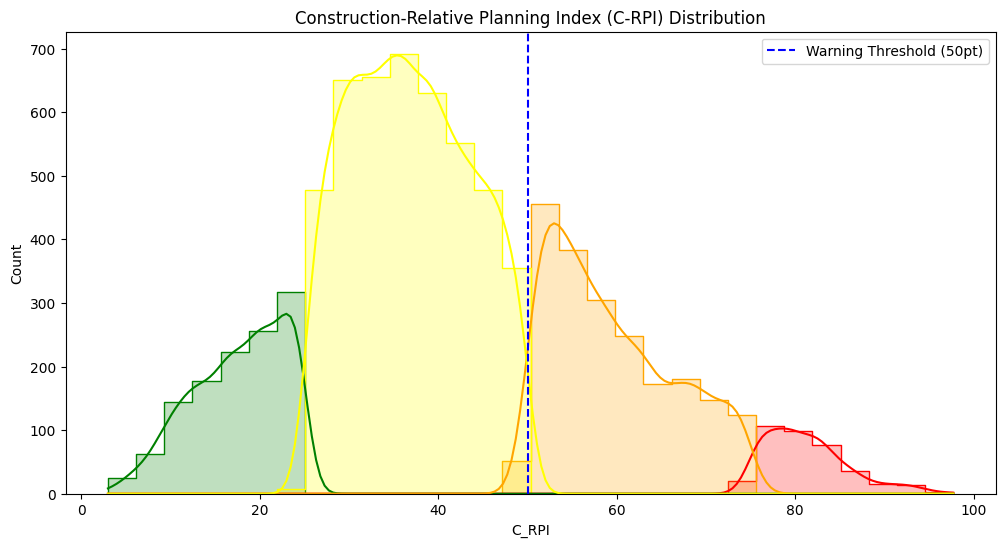

C-RPI 지수화 및 등급 분류 완료


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 모델의 예측 확률값(probs)을 바탕으로 지수 산출
def get_crpi_index(probs, threshold):
    """
    확률값을 0~100 사이의 C-RPI 지수로 변환.
    임계값(threshold) 지점을 50점으로 설정하여 직관성 확보.
    """
    indices = []
    for p in probs:
        if p < threshold:
            # 임계값 미만: 0 ~ 50점 사이로 스케일링
            score = (p / threshold) * 50
        else:
            # 임계값 이상: 50 ~ 100점 사이로 스케일링
            score = 50 + ((p - threshold) / (1 - threshold)) * 50
        indices.append(np.round(score, 2))
    return np.array(indices)

# 2. 지수 적용 및 등급 분류
# optimal_threshold는 앞서 구한 값(예: 0.2 또는 0.45 등)을 사용
c_rpi_scores = get_crpi_index(probs, optimal_threshold)

def get_risk_grade(score):
    if score < 25: return '관심(초록)'
    elif score < 50: return '주의(노랑)'
    elif score < 75: return '경계(주황)'
    else: return '심각(빨강)'

risk_grades = [get_risk_grade(s) for s in c_rpi_scores]

# 3. 결과 데이터프레임 구축
final_result = pd.DataFrame({
    'Actual_Accident': y_test,
    'Raw_Probability': probs,
    'C_RPI': c_rpi_scores,
    'Grade': risk_grades
})

# 4. 결과 시각화 (기획서용 위험 지수 분포도)
plt.figure(figsize=(12, 6))
sns.histplot(data=final_result, x='C_RPI', hue='Grade',
             palette={'관심(초록)':'green', '주의(노랑)':'yellow', '경계(주황)':'orange', '심각(빨강)':'red'},
             bins=30, kde=True, element="step")
plt.axvline(50, color='blue', linestyle='--', label='Warning Threshold (50pt)')
plt.title('Construction-Relative Planning Index (C-RPI) Distribution')
plt.legend()
plt.show()

print("C-RPI 지수화 및 등급 분류 완료")

In [6]:
!pip install autogluon

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 kB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of opentelemetry-sdk to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of openxlab to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.5/259.5 kB 8.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is still looking at multiple versions of openxlab to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longe

In [ ]:
import pandas as pd
from autogluon.tabular import TabularPredictor
from sklearn.model_selection import train_test_split

# 1. 데이터 로드 및 누수 방지 (이전과 동일하게 사후 데이터 제거)
df = pd.read_csv('/content/drive/MyDrive/전북대학교/공모전/경상국립대 ai,빅데이터 활용 서비스 개발/RIA_최종통합피쳐셋.csv').fillna(0)
leakage_cols = ['사망자', '부상자', '총재해자', '외국인재해자', '외국인비율', '고령재해자', '고령자비율',
                '남성 사망자', '남성 부상자', '여성 사망자', '여성 부상자', '추락_낙하', '붕괴_도괴',
                '구조물_균열', '침수_수해', '장비_충돌', '화재_폭발', '기타', 'C_RPI', '위험등급']
df_clean = df.drop(columns=leakage_cols, errors='ignore')

# 2. Train/Test Split
train_data, test_data = train_test_split(df_clean, test_size=0.2, random_state=42, stratify=df_clean['중대재해'])

# 3. AutoGluon 학습 시작
# eval_metric='average_precision'을 사용하여 불균형 데이터셋에 최적화된 모델을 찾습니다.
label = '중대재해'
predictor = TabularPredictor(
    label=label,
    problem_type='binary',
    eval_metric='average_precision'
).fit(
    train_data=train_data.drop(columns=['사고일시']),
    presets='best_quality', # 앙상블 및 스택킹을 사용하여 성능을 극한으로 끌어올림
    time_limit=600 # 10분 동안 최적의 모델 탐색 (시간은 조절 가능)
)

# 4. 모델 리더보드 확인 (어떤 모델이 이겼는지 확인)
leaderboard = predictor.leaderboard(test_data, silent=True)
print(leaderboard)

# 5. 최적 모델로 성능 평가
performance = predictor.evaluate(test_data)
print(f"\n최종 평가 결과: {performance}")

# 6. 예측 확률값 도출 (이후 지수화에 사용)
probs = predictor.predict_proba(test_data)[:, 1]

No path specified. Models will be saved in: "AutogluonModels/ag-20260507_035550"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.13
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Mon Feb  2 12:27:57 UTC 2026
CPU Count:          2
Pytorch Version:    2.9.1+cu128
CUDA Version:       CUDA is not available
Memory Avail:       10.45 GB / 12.67 GB (82.5%)
Disk Space Avail:   75.27 GB / 107.72 GB (69.9%)
Presets specified: ['best_quality']
Using hyperparameters preset: hyperparameters='zeroshot'
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
DyStack is enabled (dynamic_stacking=True). AutoGluon will try to determine whether the input data is affected by stacked overfitting and enable or disable sta

                     model  score_test  score_val        eval_metric  \
0        LightGBMXT_BAG_L1    0.182009   0.157909  average_precision   
1      WeightedEnsemble_L2    0.178084   0.173017  average_precision   
2          CatBoost_BAG_L1    0.172725   0.162105  average_precision   
3          LightGBM_BAG_L1    0.170742   0.163813  average_precision   
4   NeuralNetFastAI_BAG_L1    0.143935   0.110081  average_precision   
5    ExtraTreesGini_BAG_L1    0.099845   0.110178  average_precision   
6    ExtraTreesEntr_BAG_L1    0.098143   0.108930  average_precision   
7  RandomForestGini_BAG_L1    0.092314   0.099866  average_precision   
8  RandomForestEntr_BAG_L1    0.091627   0.099223  average_precision   

   pred_time_test  pred_time_val    fit_time  pred_time_test_marginal  \
0        1.491953       0.389603   50.312934                 1.491953   
1        5.062307       3.208885  323.991901                 0.009592   
2        0.300978       0.157470  161.769708                

InvalidIndexError: (slice(None, None, None), 1)

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_recall_curve

# 1. 에러 수정: 확률값 추출 (Pandas DataFrame 대응)
# AutoGluon의 predict_proba는 클래스 이름이 컬럼명인 DF를 반환합니다.
probs_df = predictor.predict_proba(test_data)
# 보통 중대재해 여부가 1이므로, 컬럼명 1 또는 두 번째 컬럼을 선택합니다.
probs = probs_df.iloc[:, 1].values

# 2. 최적 임계값(Threshold) 재설정
# 성능이 올라갔으므로, 다시 한번 Recall 0.6 지점을 찾습니다.
y_test = test_data['중대재해']
precisions, recalls, thresholds = precision_recall_curve(y_test, probs)

target_recall = 0.6
idx = np.where(recalls >= target_recall)[0][-1]
optimal_threshold = thresholds[idx]

# 3. C-RPI 지수 산출 (Calibration 로직)
def calculate_final_crpi(prob_array, threshold):
    # 임계값을 50점으로 정규화하여 리스크의 가시성 확보
    scores = np.where(prob_array >= threshold,
                      50 + (prob_array - threshold) / (1 - threshold) * 50,
                      (prob_array / threshold) * 50)
    return np.round(scores, 2)

final_crpi = calculate_final_crpi(probs, optimal_threshold)

# 4. 등급 부여 및 결과 통합
def get_grade(s):
    if s < 25: return '관심'
    elif s < 50: return '주의'
    elif s < 75: return '경계'
    else: return '심각'

test_res = test_data.copy()
test_res['C_RPI'] = final_crpi
test_res['Risk_Grade'] = [get_grade(s) for s in final_crpi]

# 5. 결과 시각화
plt.figure(figsize=(10, 6))
sns.histplot(data=test_res, x='C_RPI', hue='Risk_Grade',
             palette={'관심':'green', '주의':'yellow', '경계':'orange', '심각':'red'},
             bins=30, kde=True)
plt.title(f'Final C-RPI System (AutoGluon Ensemble, AUPRC: 0.178)')
plt.show()

print(f"최적 임계값: {optimal_threshold:.4f}")
print(test_res[['중대재해', 'C_RPI', 'Risk_Grade']].head(10))

NameError: name 'test_data' is not defined

In [15]:
import pandas as pd
from sklearn.model_selection import train_test_split
from autogluon.tabular import TabularPredictor
import numpy as np

# 1. 데이터 로드 (경로 확인 필수)
data_path = '/content/drive/MyDrive/전북대학교/공모전/경상국립대 ai,빅데이터 활용 서비스 개발/RIA_최종통합피쳐셋.csv'
df_raw = pd.read_csv(data_path).fillna(0)

# 2. 누수 컬럼 제거 (학습 때와 동일하게)
leakage_cols = ['사망자', '부상자', '총재해자', '외국인재해자', '외국인비율', '고령재해자', '고령자비율',
                '남성 사망자', '남성 부상자', '여성 사망자', '여성 부상자', '추락_낙하', '붕괴_도괴',
                '구조물_균열', '침수_수해', '장비_충돌', '화재_폭발', '기타', 'C_RPI', '위험등급']
df_clean = df_raw.drop(columns=leakage_cols, errors='ignore')

# 3. 데이터 분할 (random_state=42 필수)
# 중대재해 변수가 타겟입니다.
train_data, test_data = train_test_split(df_clean, test_size=0.2, random_state=42, stratify=df_clean['중대재해'])

print(f"test_data 재구축 완료: {len(test_data)}건")

test_data 재구축 완료: 8143건


In [11]:
# 1. 모델 저장 (학습 시 경로 지정했다면 그 폴더에 이미 저장되어 있음)
# predictor.save() # 이미 학습 시 자동 저장됨

# 2. 모델 로드 (나중에 다시 쓸 때)
from autogluon.tabular import TabularPredictor
predictor = TabularPredictor.load("/content/drive/MyDrive/전북대학교/공모전/경상국립대 ai,빅데이터 활용 서비스 개발/ag-20260507_035550") # 실제 폴더명 입력

In [16]:
from sklearn.metrics import classification_report

# 테스트 데이터에 대한 예측 확률 및 최종 라벨 도출
probs = predictor.predict_proba(test_data).iloc[:, 1]
final_preds = (probs >= 0.0427).astype(int)

print("=== AutoGluon 최종 성능 보고서 ===")
print(classification_report(test_data['중대재해'], final_preds))

=== AutoGluon 최종 성능 보고서 ===
              precision    recall  f1-score   support

           0       0.98      0.76      0.85      7808
           1       0.10      0.60      0.16       335

    accuracy                           0.75      8143
   macro avg       0.54      0.68      0.51      8143
weighted avg       0.94      0.75      0.82      8143

